# Generative Adversarial Network (GAN) on CIFAR-10

In this notebook, I implemented a Deep Convolutional GAN (DCGAN) using TensorFlow/Keras and trained it on the CIFAR-10 (32x32x3) dataset.

The goal of this project was to generate images by building both the Generator and Discriminator from scratch.

While working on this project, I also ran into several real-world training/debugging challenges related to GPU memory usage, CUDA instability, and long-duration GAN training on local hardware, which ended up being a useful learning experience on its own.

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import Flatten
from tensorflow. keras.layers import Dropout
from tensorflow. keras.layers import Reshape
from tensorflow.keras.layers import LeakyReLU
from keras.datasets.cifar10 import load_data


import matplotlib.pyplot as plt

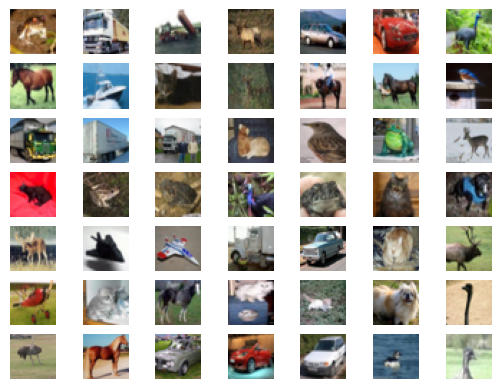

In [4]:
(trainX, trainy), (testX, testy) = load_data()

for i in range(49):
    plt.subplot(7, 7, 1 + i)
    plt.axis("off")
    plt.imshow(trainX[i])
plt.show()

In [5]:
print(trainX.shape)

(50000, 32, 32, 3)


In [6]:
def define_discriminator(in_shape=(32, 32, 3)):
    model = Sequential()
    #Normal
    model.add(Conv2D(64, (3, 3), padding='same', input_shape=in_shape))
    model.add(LeakyReLU(alpha=0.2))
    #Downsample
    model.add(Conv2D(128, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    #Downsample
    model.add(Conv2D(128, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    #Downsample
    model.add(Conv2D(256, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    #Classifier
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
        metrics=['accuracy']
    )

    return model

In [7]:
model = define_discriminator()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        1792      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 128)       73856     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 16, 16, 128)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         147584    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 8, 8, 128)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 4, 4, 256)         2

In [8]:
def load_real_samples():
    (train_X, _),(_, _) = load_data()
    X = train_X.astype("float32")
    X = (X - 127.5) / 127.5
    return X
X = load_real_samples()
X.shape

(50000, 32, 32, 3)

In [9]:
def generate_real_samples(dataset, n_samples):
    ix = np.random.randint(0, dataset.shape[0], n_samples)
    X = dataset[ix]
    y = np.ones((n_samples, 1))

    return X, y  

In [10]:
dataset = load_real_samples()

In [11]:
def define_generator(latent_dim):
    model = Sequential()

    model.add(Dense(256 * 4 * 4, input_dim = latent_dim))
    model.add(LeakyReLU(alpha = 0.2))
    model.add(Reshape((4, 4, 256)))
    #Upsample to 8*8
    model.add(Conv2DTranspose(128, (4,4), strides = (2,2), padding = "same"))
    model.add(LeakyReLU(alpha = 0.2))
    #upsample to 16*16
    model.add(Conv2DTranspose(128, (4,4), strides = (2,2), padding = "same"))
    model.add(LeakyReLU(alpha = 0.2))
    #upsample to 32*32
    model.add(Conv2DTranspose(128, (4,4), strides = (2,2), padding = "same"))
    model.add(LeakyReLU(alpha = 0.2))

    #output layer
    model.add(Conv2D(3, (3,3), activation = "tanh", padding = "same"))

    return model

In [12]:
latent_dim = 100
model = define_generator(latent_dim)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 4096)              413696    
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 4096)              0         
                                                                 
 reshape (Reshape)           (None, 4, 4, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 8, 8, 128)        524416    
 nspose)                                                         
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 8, 8, 128)         0         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 16, 16, 128)      262272    
 ranspose)                                            

In [13]:
def generate_latent_points(latent_dim, n_samples):

    x_input = np.random.randn(latent_dim *n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

def generate_fake_samples(g_model, latent_dim, n_samples):
    x_input = generate_latent_points(latent_dim, n_samples)
    X = g_model.predict(x_input)

    y = np.zeros((n_samples, 1))
    return X, y


2/2 [==============================] - 4s 216ms/step


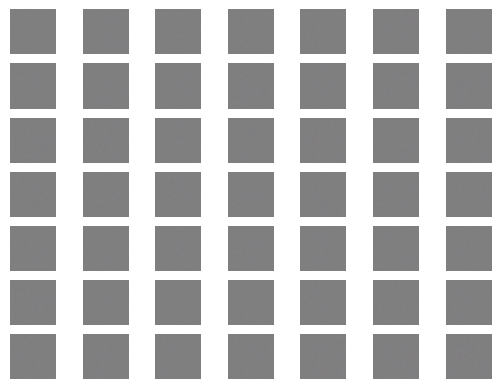

In [14]:
latent_dim = 100
model = define_generator(latent_dim)
n_samples = 49

X, _ = generate_fake_samples(model, latent_dim, n_samples)

X = (X + 1) / 2.0 #scale pixrel value from [-1,1] to [0, 1]

for i in range(n_samples):
    plt.subplot(7, 7, 1+i)
    plt.axis("off")
    plt.imshow(X[i])
plt.show()

In [15]:
def define_gan(g_model, d_model):
    d_model.trainable = False
    model = Sequential()
    model.add(g_model)
    model.add(d_model)

    model.compile(
                loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
                metrics=['accuracy']
    )
    return model

In [16]:
latent_dim = 100
d_model = define_discriminator()
g_model = define_generator(latent_dim)
gan_model = define_gan(g_model, d_model)
gan_model.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_4 (Sequential)   (None, 32, 32, 3)         1466115   
                                                                 
 sequential_3 (Sequential)   (None, 1)                 522497    
                                                                 
Total params: 1,988,612
Trainable params: 1,466,115
Non-trainable params: 522,497
_________________________________________________________________


In [17]:
# evaluate the discriminator, plot generated images, save generator model
def summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples=150):
    # prepare real samples
    X_real, y_real = generate_real_samples(dataset, n_samples)
    # evaluate discriminator on real examples
    _, acc_real = d_model.evaluate(X_real, y_real, verbose=0)
    # prepare fake examples
    x_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_samples)
    # evaluate discriminator on fake examples
    _, acc_fake = d_model.evaluate(x_fake, y_fake, verbose=0)
    # summarize discriminator performance
    print('>Accuracy real: %.0f%%; fake: %.0f%%' % (acc_real*100, acc_fake*100))
    # save plot
    save_plot(x_fake, epoch)
    # save the generator model tile file
    filename = 'generator_model_%03d.h5' % (epoch+1)
    g_model.save(filename)

# create and save a plot of generated images
# create and save a plot of generated images
def save_plot(examples, epoch, n=7):
    # scale from [-1,1] to [0,1]
    examples = (examples + 1) / 2.0
    # plot images
    for i in range(n * n):
        # define subplot
        plt.subplot(n, n, 1 + i)
        # turn off axis
        plt.axis('off')
        # plot raw pixel data
        plt.imshow(examples[i])
    # save plot to file
    filename = 'generated_plot_e%03d.png' % (epoch+1)
    plt.savefig(filename)
    plt.close()

In [19]:
import os
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=200, n_batch=32):

    batch_per_epoch = int(dataset.shape[0] / n_batch)
    half_batch = int(n_batch / 2)

    for i in range(n_epochs):

        for j in range(batch_per_epoch):

            X_real, y_real = generate_real_samples(dataset, half_batch)
            d_loss1, _ = d_model.train_on_batch(X_real, y_real)

            X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
            d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)

            X_gan = generate_latent_points(latent_dim, n_batch)
            y_gan = np.ones((n_batch, 1))

            g_loss = gan_model.train_on_batch(X_gan, y_gan)

            print(f'>{i+1}, {j+1}/{batch_per_epoch}, '
                  f'd1_real={d_loss1:.3f}, d2_fake={d_loss2:.3f}, g_loss={g_loss[0]:.3f}')

        g_model.save("generator_latest.h5")
        d_model.save("discriminator_latest.h5")
        gan_model.save("gan_latest.h5")

        # 💾 SAVE TRAINING STATE
        with open("epoch_state.txt", "w") as f:
            f.write(str(i + 1))

        print(f"Checkpoint saved at epoch {i+1}")

In [ ]:
train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=100, n_batch = 32)

1/1 [==============================] - 0s 247ms/step
>1, 1/1562, d1_real=0.694, d2_fake=0.695, g_loss=0.691
1/1 [==============================] - 0s 14ms/step
>1, 2/1562, d1_real=0.620, d2_fake=0.698, g_loss=0.689
1/1 [==============================] - 0s 14ms/step
>1, 3/1562, d1_real=0.561, d2_fake=0.703, g_loss=0.684
1/1 [==============================] - 0s 15ms/step
>1, 4/1562, d1_real=0.500, d2_fake=0.716, g_loss=0.674
1/1 [==============================] - 0s 13ms/step
>1, 5/1562, d1_real=0.413, d2_fake=0.742, g_loss=0.654
1/1 [==============================] - 0s 24ms/step
>1, 6/1562, d1_real=0.299, d2_fake=0.790, g_loss=0.626
1/1 [==============================] - 0s 27ms/step
>1, 7/1562, d1_real=0.158, d2_fake=0.834, g_loss=0.627
1/1 [==============================] - 0s 14ms/step
>1, 8/1562, d1_real=0.176, d2_fake=0.808, g_loss=0.677
1/1 [==============================] - 0s 14ms/step
>1, 9/1562, d1_real=0.121, d2_fake=0.699, g_loss=0.808
1/1 [==============================]

## Training Notes

The model architecture and training pipeline worked correctly, and training was successfully running on GPU (NVIDIA RTX A3000 Laptop GPU). However, I was not able to complete long uninterrupted training runs consistently on my local machine due to repeated GPU/driver related crashes during extended training sessions.

Some of the issues encountered during training included:

- CUDA memory/access errors
- Jupyter kernel crashes
- occasional Windows restarts/BSOD during heavy GPU load
- GPU driver timeout related issues (`dxgkrnl.sys`, `watchdog.sys`)

After debugging and testing different configurations, reducing batch size from 128 to 32 improved stability significantly, which suggests the crashes were likely related to GPU memory pressure and sustained load on the laptop GPU during GAN training.

While the model architecture is correct and training pipeline is functional, stable long-duration training on local hardware was not fully achievable due to GPU driver and hardware constraints.

Future improvements could include:

- Training on cloud GPU instances
- Switching to more stable GAN variants like WGAN-GP
- Further optimization of memory usage and training stability